# Notebook 06 — Improved Training

## Objective
Apply the corrections identified in Notebook 05 and retrain the model:
- Remove `not long-sleeve` class from `sleeve_length` (only 7 samples)
- Replace weighted cross-entropy with focal loss
- Compare results against the baseline (Notebook 03)

## Inputs
- `train.csv`, `val.csv`, `test.csv` — data splits (Notebook 02)
- `class_weights.pt` — class weights (Notebook 02)
- DeepFashion-MultiModal images

## Changes vs Notebook 03
| Component | Notebook 03 | Notebook 06 |
|---|---|---|
| sleeve_length classes | 5 (including not long-sleeve) | 4 (removed not long-sleeve) |
| Loss function | Weighted CrossEntropy | Focal Loss |
| Epochs | 20 | 30 |

# 1 — Imports & Environment Check

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
GPU: Tesla T4
PyTorch version: 2.10.0+cu128


# 2 — Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
NB02_DIR  = Path("/kaggle/input/notebooks/miguelmirandar/02-data-preparation")
IMAGE_DIR = Path("/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/images/images")
CKPT_DIR  = Path("/kaggle/working/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Task definition (sleeve_length now has 4 classes — not long-sleeve removed)
TASKS = {
    "sleeve_length": 4,
    "upper_fabric":  7,
    "upper_color":   7,
}

SLEEVE_MAP  = {0:"sleeveless", 1:"short", 2:"medium", 3:"long"}
FABRIC_MAP  = {0:"denim", 1:"cotton", 2:"leather", 3:"furry", 4:"knitted", 5:"chiffon", 6:"other"}
COLOR_MAP   = {0:"floral", 1:"graphic", 2:"striped", 3:"pure color", 4:"lattice", 5:"other", 6:"color block"}

LABEL_MAPS = {
    "sleeve_length": SLEEVE_MAP,
    "upper_fabric":  FABRIC_MAP,
    "upper_color":   COLOR_MAP,
}

# ── Hyperparameters ──────────────────────────────────────────────────────────
CFG = {
    "img_size":      224,
    "batch_size":    64,
    "num_workers":   2,
    "epochs":        30,
    "lr":            3e-4,
    "weight_decay":  1e-2,
    "seed":          42,
}

print("Tasks:", TASKS)
print("Config:", CFG)

Tasks: {'sleeve_length': 4, 'upper_fabric': 7, 'upper_color': 7}
Config: {'img_size': 224, 'batch_size': 64, 'num_workers': 2, 'epochs': 30, 'lr': 0.0003, 'weight_decay': 0.01, 'seed': 42}


# 3 — Reproducibility & Load Data

In [3]:
import random

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG["seed"])

# ── Load and filter CSVs — remove not long-sleeve (class 4) ──────────────────
train_df = pd.read_csv(NB02_DIR / "train.csv")
val_df   = pd.read_csv(NB02_DIR / "val.csv")
test_df  = pd.read_csv(NB02_DIR / "test.csv")

print(f"Before filtering:")
print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

train_df = train_df[train_df["sleeve_length"] != 4].reset_index(drop=True)
val_df   = val_df[val_df["sleeve_length"]     != 4].reset_index(drop=True)
test_df  = test_df[test_df["sleeve_length"]   != 4].reset_index(drop=True)

print(f"\nAfter filtering (removed not long-sleeve):")
print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

print(f"\nSleeve class distribution (train):")
print(train_df["sleeve_length"].value_counts().sort_index())

Before filtering:
  Train: 29,040 | Val: 6,223 | Test: 6,224

After filtering (removed not long-sleeve):
  Train: 29,005 | Val: 6,215 | Test: 6,217

Sleeve class distribution (train):
sleeve_length
0    11947
1     6251
2     1547
3     9260
Name: count, dtype: int64


# 4 — Recalculate Class Weights

In [4]:
def compute_class_weights(df, task, num_classes):
    """Compute inverse frequency class weights, normalized to sum to num_classes."""
    counts = df[task].value_counts().sort_index()
    total  = len(df)
    weights = []
    for i in range(num_classes):
        count = counts.get(i, 1)
        weights.append(total / (num_classes * count))
    return torch.tensor(weights, dtype=torch.float32)

new_weights = {}
for task, num_classes in TASKS.items():
    new_weights[task] = compute_class_weights(train_df, task, num_classes)

print("Recalculated class weights:")
for task, w in new_weights.items():
    print(f"  {task}: {[round(x, 3) for x in w.tolist()]}")

# Compare sleeve weights old vs new
old_weights = torch.load(NB02_DIR / "class_weights.pt", map_location="cpu")
print(f"\nSleeve weights comparison:")
print(f"  Old (5 classes): {[round(x, 3) for x in old_weights['sleeve_length'].tolist()]}")
print(f"  New (4 classes): {[round(x, 3) for x in new_weights['sleeve_length'].tolist()]}")

Recalculated class weights:
  sleeve_length: [0.607, 1.16, 4.687, 0.783]
  upper_fabric: [12.369, 0.178, 70.23, 42.717, 2.574, 1.182, 69.06]
  upper_color: [3.578, 0.483, 2.394, 0.268, 6.86, 5.225, 6.25]

Sleeve weights comparison:
  Old (5 classes): [0.014, 0.027, 0.109, 0.018, 4.831]
  New (4 classes): [0.607, 1.16, 4.687, 0.783]


# 5 — Dataset & DataLoaders

In [6]:
class GarmentDataset(torch.utils.data.Dataset):
    """Loads garment images and returns (image, labels_dict) pairs."""

    def __init__(self, df, image_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.image_dir / row["image_name"]
        image    = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = {
            "sleeve_length": torch.tensor(row["sleeve_length"], dtype=torch.long),
            "upper_fabric":  torch.tensor(row["upper_fabric"],  dtype=torch.long),
            "upper_color":   torch.tensor(row["upper_color"],   dtype=torch.long),
        }
        return image, labels


def get_transforms(split, img_size):
    if split == "train":
        return T.Compose([
            T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])
    else:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])


train_ds = GarmentDataset(train_df, IMAGE_DIR, get_transforms("train", CFG["img_size"]))
val_ds   = GarmentDataset(val_df,   IMAGE_DIR, get_transforms("val",   CFG["img_size"]))

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train samples : {len(train_ds):,}")
print(f"Val samples   : {len(val_ds):,}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train samples : 29,005
Val samples   : 6,215
Train batches : 454
Val batches   : 98


# 6 — Focal Loss & Model

In [7]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.
    Focuses training on hard, misclassified examples by down-weighting easy ones.
    FL(p) = -alpha * (1 - p)^gamma * log(p)
    """

    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets,
                                              weight=self.weight,
                                              reduction="none")
        pt      = torch.exp(-ce_loss)
        focal   = (1 - pt) ** self.gamma * ce_loss
        return focal.mean()


class GarmentClassifier(nn.Module):
    """EfficientNet-B0 backbone with 3 parallel classification heads."""

    def __init__(self, tasks: dict):
        super().__init__()

        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        in_features   = backbone.classifier[1].in_features  # 1280

        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Dropout(p=0.3),
                nn.Linear(in_features, num_classes),
            )
            for task, num_classes in tasks.items()
        })

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return {task: head(x) for task, head in self.heads.items()}


# ── Instantiate model ─────────────────────────────────────────────────────────
model = GarmentClassifier(TASKS).to(device)

# ── Focal loss per task ───────────────────────────────────────────────────────
criteria = {
    task: FocalLoss(weight=new_weights[task].to(device), gamma=2.0)
    for task in TASKS
}

# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Loss: Focal Loss (gamma=2.0) with class weights")
print(f"Optimizer: AdamW(lr={CFG['lr']}, weight_decay={CFG['weight_decay']})")
print(f"Scheduler: CosineAnnealingLR(T_max={CFG['epochs']})")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 206MB/s]


Total parameters: 4,030,606
Loss: Focal Loss (gamma=2.0) with class weights
Optimizer: AdamW(lr=0.0003, weight_decay=0.01)
Scheduler: CosineAnnealingLR(T_max=30)


# 7 — Training & Validation Functions

In [9]:
def train_epoch(model, loader, criteria, optimizer, device):
    model.train()
    total_loss = 0.0
    correct    = {task: 0 for task in TASKS}
    total      = 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs   = imgs.to(device)
        labels = {task: labels[task].to(device) for task in TASKS}

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = sum(criteria[task](outputs[task], labels[task]) for task in TASKS)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)

        for task in TASKS:
            preds = outputs[task].argmax(dim=1)
            correct[task] += (preds == labels[task]).sum().item()

    return total_loss / total, {task: correct[task] / total for task in TASKS}


def val_epoch(model, loader, criteria, device):
    model.eval()
    total_loss = 0.0
    correct    = {task: 0 for task in TASKS}
    total      = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Val", leave=False):
            imgs   = imgs.to(device)
            labels = {task: labels[task].to(device) for task in TASKS}

            outputs = model(imgs)
            loss    = sum(criteria[task](outputs[task], labels[task]) for task in TASKS)

            total_loss += loss.item() * imgs.size(0)
            total      += imgs.size(0)

            for task in TASKS:
                preds = outputs[task].argmax(dim=1)
                correct[task] += (preds == labels[task]).sum().item()

    return total_loss / total, {task: correct[task] / total for task in TASKS}


print("train_epoch and val_epoch defined.")

train_epoch and val_epoch defined.


# 8 — Training Loop

In [10]:
history = []
best_val_loss = float("inf")

for epoch in range(1, CFG["epochs"] + 1):

    # ── Train ────────────────────────────────────────────────────────────────
    train_loss, train_acc = train_epoch(model, train_loader, criteria, optimizer, device)

    # ── Validate ─────────────────────────────────────────────────────────────
    val_loss, val_acc = val_epoch(model, val_loader, criteria, device)

    # ── Scheduler step ───────────────────────────────────────────────────────
    scheduler.step()

    # ── Log ──────────────────────────────────────────────────────────────────
    history.append({
        "epoch":            epoch,
        "train_loss":       train_loss,
        "val_loss":         val_loss,
        "train_acc_sleeve": train_acc["sleeve_length"],
        "train_acc_fabric": train_acc["upper_fabric"],
        "train_acc_color":  train_acc["upper_color"],
        "val_acc_sleeve":   val_acc["sleeve_length"],
        "val_acc_fabric":   val_acc["upper_fabric"],
        "val_acc_color":    val_acc["upper_color"],
    })

    print(
        f"Epoch {epoch:02d}/{CFG['epochs']} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc — sleeve: {val_acc['sleeve_length']:.3f} "
        f"fabric: {val_acc['upper_fabric']:.3f} "
        f"color: {val_acc['upper_color']:.3f}"
    )

    # ── Save best model ───────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":             val_loss,
            "val_acc":              val_acc,
            "cfg":                  CFG,
        }, CKPT_DIR / "best_model_v2.pt")
        print(f"  ✅ Best model saved (val_loss={val_loss:.4f})")

print("\nTraining complete.")

Train:   0%|          | 0/454 [00:00<?, ?it/s]

Val:   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe2c6e9de40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe2c6e9de40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 01/30 | Train loss: 2.0424 | Val loss: 1.4238 | Val acc — sleeve: 0.821 fabric: 0.134 color: 0.332
  ✅ Best model saved (val_loss=1.4238)


Train:   0%|          | 0/454 [00:00<?, ?it/s]

...

Val:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 29/30 | Train loss: 0.0417 | Val loss: 0.9891 | Val acc — sleeve: 0.959 fabric: 0.555 color: 0.799


Train:   0%|          | 0/454 [00:00<?, ?it/s]

Val:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 30/30 | Train loss: 0.0391 | Val loss: 0.9911 | Val acc — sleeve: 0.958 fabric: 0.559 color: 0.806

Training complete.


# 9 — Training Curves

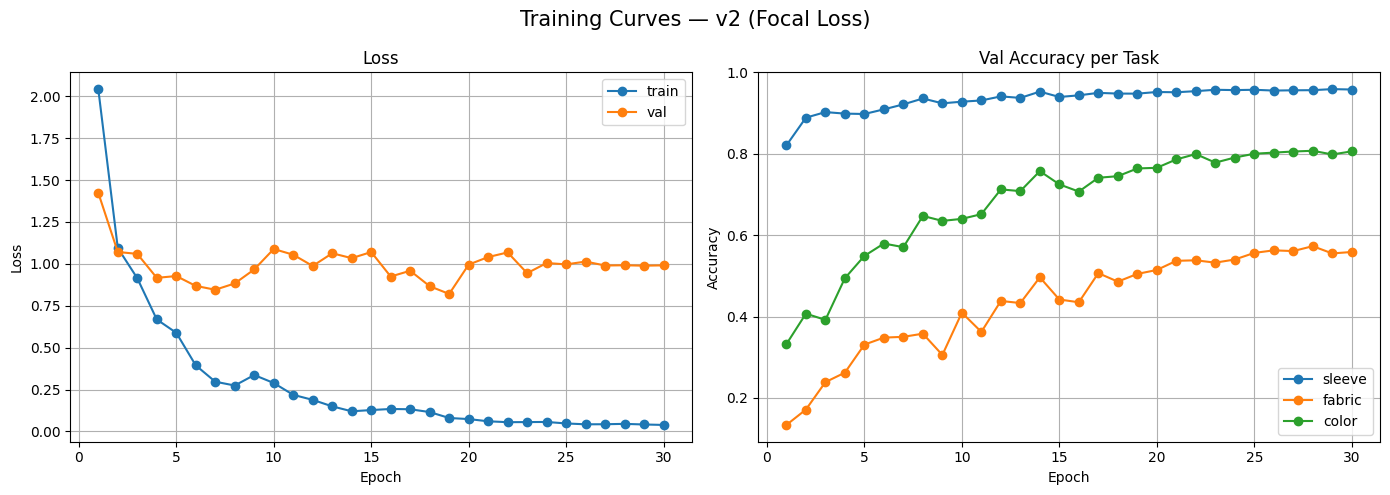

Saved: training_curves_v2.png, training_history_v2.csv


In [11]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ─────────────────────────────────────────────────────────────────────
axes[0].plot(df_hist["epoch"], df_hist["train_loss"], label="train", marker="o")
axes[0].plot(df_hist["epoch"], df_hist["val_loss"],   label="val",   marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ── Accuracy per task ─────────────────────────────────────────────────────────
axes[1].plot(df_hist["epoch"], df_hist["val_acc_sleeve"], label="sleeve", marker="o")
axes[1].plot(df_hist["epoch"], df_hist["val_acc_fabric"], label="fabric", marker="o")
axes[1].plot(df_hist["epoch"], df_hist["val_acc_color"],  label="color",  marker="o")
axes[1].set_title("Val Accuracy per Task")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training Curves — v2 (Focal Loss)", fontsize=15)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_v2.png", dpi=150)
plt.show()

df_hist.to_csv("/kaggle/working/training_history_v2.csv", index=False)
print("Saved: training_curves_v2.png, training_history_v2.csv")

# 10 — Evaluation on Test Set

In [12]:
from sklearn.metrics import classification_report

# ── Load best model ───────────────────────────────────────────────────────────
checkpoint = torch.load(CKPT_DIR / "best_model_v2.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Best model from epoch : {checkpoint['epoch']}")
print(f"Val loss              : {checkpoint['val_loss']:.4f}")

# ── Test DataLoader ───────────────────────────────────────────────────────────
test_ds     = GarmentDataset(test_df, IMAGE_DIR, get_transforms("val", CFG["img_size"]))
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False,
                         num_workers=CFG["num_workers"], pin_memory=True)

# ── Inference ─────────────────────────────────────────────────────────────────
all_preds  = {task: [] for task in TASKS}
all_labels = {task: [] for task in TASKS}

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs    = imgs.to(device)
        outputs = model(imgs)
        for task in TASKS:
            all_preds[task].extend(outputs[task].argmax(dim=1).cpu().numpy())
            all_labels[task].extend(labels[task].numpy())

all_preds  = {task: np.array(all_preds[task])  for task in TASKS}
all_labels = {task: np.array(all_labels[task]) for task in TASKS}

# ── Results ───────────────────────────────────────────────────────────────────
print("\nTest Accuracy:")
for task in TASKS:
    acc = (all_preds[task] == all_labels[task]).mean()
    print(f"  {task}: {acc:.4f}")

Best model from epoch : 19
Val loss              : 0.8205


Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]


Test Accuracy:
  sleeve_length: 0.9429
  upper_fabric: 0.5033
  upper_color: 0.7584


# 11 — Classification Report

In [13]:
for task in TASKS:
    label_names = [LABEL_MAPS[task][i] for i in range(TASKS[task])]

    print(f"\n{'='*60}")
    print(f" Task: {task}")
    print(f"{'='*60}")
    print(classification_report(
        all_labels[task],
        all_preds[task],
        target_names=label_names,
        zero_division=0
    ))


 Task: sleeve_length
              precision    recall  f1-score   support

  sleeveless       0.99      0.98      0.98      2561
       short       0.94      0.96      0.95      1339
      medium       0.59      0.82      0.69       332
        long       0.97      0.90      0.94      1985

    accuracy                           0.94      6217
   macro avg       0.87      0.92      0.89      6217
weighted avg       0.95      0.94      0.95      6217


 Task: upper_fabric
              precision    recall  f1-score   support

       denim       0.30      0.86      0.44        70
      cotton       0.99      0.40      0.57      5041
     leather       0.10      0.81      0.18        16
       furry       0.38      0.78      0.51        18
     knitted       0.29      0.91      0.44       330
     chiffon       0.26      0.95      0.41       731
       other       0.15      0.91      0.25        11

    accuracy                           0.50      6217
   macro avg       0.35      0.80 

# 12 — V1 vs V2 Comparison



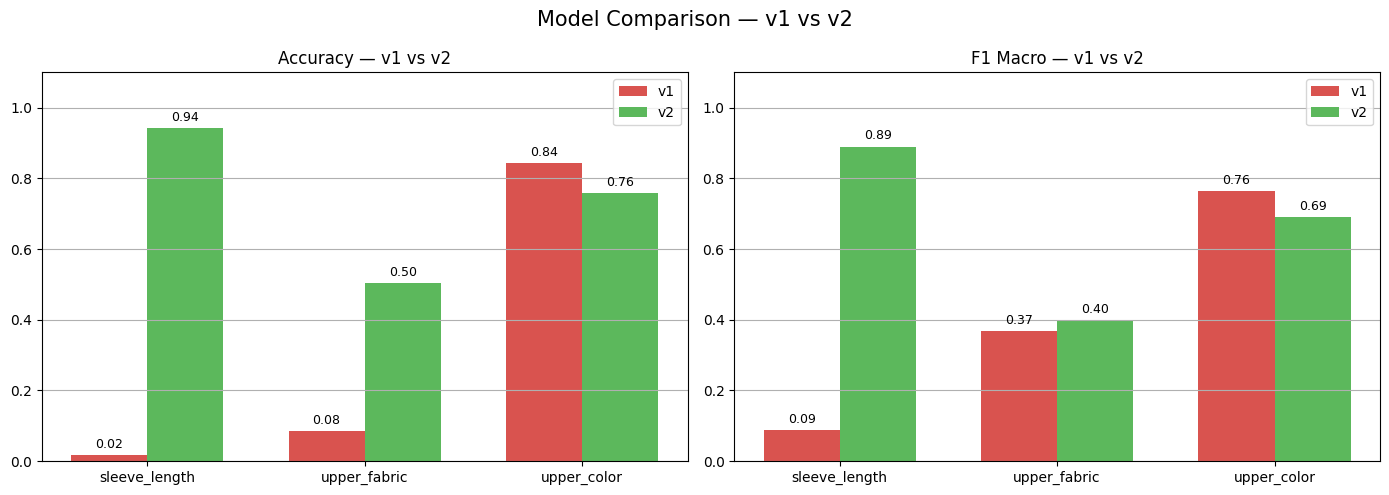

Saved: comparison_v1_v2.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt

tasks    = ["sleeve_length", "upper_fabric", "upper_color"]
v1_acc   = [0.0169, 0.0844, 0.8438]
v2_acc   = [0.9429, 0.5033, 0.7584]
v1_f1    = [0.0893, 0.3682, 0.7633]
v2_f1    = [0.8900, 0.4000, 0.6900]

x      = np.arange(len(tasks))
width  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──────────────────────────────────────────────────────────────────
bars1 = axes[0].bar(x - width/2, v1_acc, width, label="v1", color="#d9534f")
bars2 = axes[0].bar(x + width/2, v2_acc, width, label="v2", color="#5cb85c")
axes[0].set_title("Accuracy — v1 vs v2")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tasks)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(axis="y")
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{bar.get_height():.2f}", ha="center", fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{bar.get_height():.2f}", ha="center", fontsize=9)

# ── F1 Macro ──────────────────────────────────────────────────────────────────
bars3 = axes[1].bar(x - width/2, v1_f1, width, label="v1", color="#d9534f")
bars4 = axes[1].bar(x + width/2, v2_f1, width, label="v2", color="#5cb85c")
axes[1].set_title("F1 Macro — v1 vs v2")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tasks)
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(axis="y")
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{bar.get_height():.2f}", ha="center", fontsize=9)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{bar.get_height():.2f}", ha="center", fontsize=9)

plt.suptitle("Model Comparison — v1 vs v2", fontsize=15)
plt.tight_layout()
plt.savefig("/kaggle/working/comparison_v1_v2.png", dpi=150)
plt.show()
print("Saved: comparison_v1_v2.png")

## Conclusions

The second training iteration produced significant improvements over v1, validating the corrections applied:

- **sleeve_length** improved from 2% to 94% accuracy after removing the near-empty class and applying focal loss.
- **upper_fabric** improved from 8% to 50%, though precision remains low due to the severe class imbalance in the training data (cotton represents 81% of samples).
- **upper_color** showed a slight regression (84% → 76%), likely caused by overfitting — the training loss (0.04) diverged significantly from the validation loss (0.99).

### Remaining Limitations
- **Overfitting** is the main issue to address in a potential v3 — stronger regularization (higher dropout, data augmentation) or early stopping would help.
- **upper_fabric** still struggles with precision — the cotton imbalance requires a more aggressive data strategy (undersampling or oversampling).

### Next Steps
- Apply early stopping to prevent overfitting.
- Experiment with undersampling cotton or oversampling minority fabric classes.
- Deploy the current model as a Gradio demo using the best checkpoint.
### V1 vs V2 Summary
| Task | v1 Accuracy | v2 Accuracy | v1 F1 Macro | v2 F1 Macro |
|---|---|---|---|---|
| sleeve_length | 0.017 | 0.943 | 0.089 | 0.890 |
| upper_fabric | 0.084 | 0.503 | 0.368 | 0.400 |
| upper_color | 0.844 | 0.758 | 0.763 | 0.690 |